In [56]:
import pandas as pd
driver_species_20 = pd.read_csv('driver_species_20.csv')
edges_df_with_relative_abundance = pd.read_csv('edges_df_with_relative_abundance.csv')
driver_species_20

,SAFE total score,number of enriched nodes,number of enriched samples,SAFE enriched score,enriched abundance ratio,enriched SAFE score ratio,mean_clr
name,,,,,,,
Proteus virus Isfahan,44.957181,64,10,39.907984,0.567990,0.887689,5.904008
Acinetobacter pittii,41.796133,48,7,39.041711,0.455081,0.934099,2.506107
Stenotrophomonas sp. WZN-1,45.766099,69,9,37.931243,10.497177,0.828807,0.123954
Abiotrophia defectiva,39.786277,55,9,37.763972,0.363366,0.949171,5.531352
Bifidobacterium dentium,40.784576,48,7,37.556436,0.453084,0.920849,4.774067
Rhizobium leguminosarum,43.989308,61,9,37.307559,0.858472,0.848105,1.406408
Bacillus sp. Lzh-5,45.927665,58,8,37.227374,0.611314,0.810565,3.668428
Fusarium graminearum,38.712166,55,9,36.876344,0.551545,0.952578,3.075677
Streptococcus sp. FDAARGOS_522,47.315420,63,9,36.689623,3.513035,0.775426,0.788188


In [1]:
mean_abundance = relative_abundance.mean(axis=1)

driver_species_20["mean_relative_abundance"] = driver_species_20.index.map(mean_abundance)

In [59]:
driver_species_20['mean_relative_abundance'].max()

0.007681306823834282

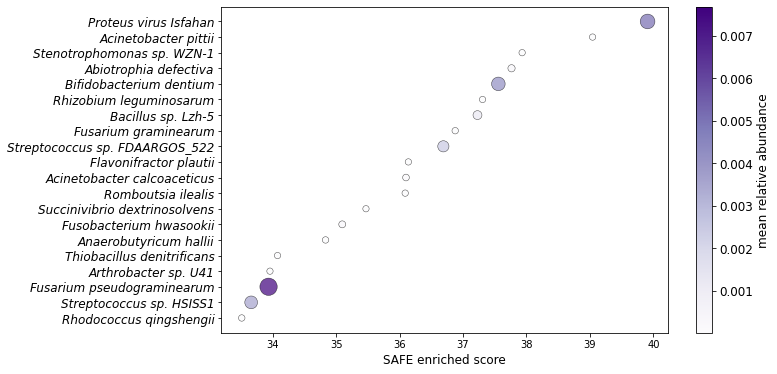

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

df_small = driver_species_20

plt.figure(figsize=(10, 6))

norm = mcolors.Normalize(vmin=driver_species_20['mean_relative_abundance'].min(), 
                         vmax=driver_species_20['mean_relative_abundance'].max())

scatter = sns.scatterplot(
    data=df_small,
    y=df_small.index,  # Microbes on y-axis
    x="SAFE enriched score",  # Score on x-axis
    size="mean_relative_abundance",  # Dot size based on mean abundance
    sizes=(40, 300),  # Adjust dot size range
    alpha=0.7,
    hue="mean_relative_abundance",  # Color the dots by abundance (optional)
    palette="Purples",  # Optional: change palette
    edgecolor="black",  # Circle borders are black
    linewidth=0.5,  # Set the thickness of the border
    legend=None,  # Disable automatic legend
)

sm = plt.cm.ScalarMappable(cmap="Purples", norm=norm)
sm.set_array([])  # Set an empty array, required by ScalarMappable
cbar = plt.colorbar(sm)
cbar.set_label("mean relative abundance", size=12)
cbar.ax.tick_params(labelsize=12)

plt.xticks()  
plt.xlabel("SAFE enriched score", size=12)
plt.ylabel("")
plt.gca().tick_params(axis='y', labelsize=12) 
plt.gca().yaxis.set_tick_params(labelrotation=0)
for label in plt.gca().get_yticklabels():
    label.set_fontstyle('italic')

plt.savefig('Driver_species_MT_COPD_BAL_patients_0405_new_clr.pdf', bbox_inches='tight')

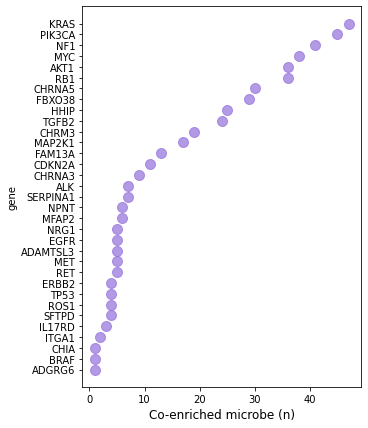

In [74]:

df = edges_df_with_relative_abundance
value_counts = df.iloc[:, 1].value_counts()

sorted_counts = value_counts.sort_values(ascending=True) 

plt.figure(figsize=(5, 7))
plt.scatter(sorted_counts.values, sorted_counts.index, color="mediumpurple", s=100, alpha=0.7)
plt.xlabel("Co-enriched microbe (n)", size=12)
plt.ylabel("gene")
plt.title("")
plt.xticks()
plt.grid(axis="y", linestyle="", alpha=0.6)

# Show plot
plt.savefig('MT_coenriched_microbe_n_forgenes_COPD_patients_new_clr.pdf',bbox_inches='tight')